In [6]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score, confusion_matrix
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

print("✅ Tất cả thư viện đã sẵn sàng!")


✅ Tất cả thư viện đã sẵn sàng!


In [9]:
import pandas as pd

# Đường dẫn tuyệt đối chính xác trỏ thẳng đến file theo cấu trúc máy của bạn
file_path = r'C:\churn_project\customer-churn-prediction\data\online_retail_II.csv'

print(f"Đang đọc dữ liệu từ: {file_path}")
df_raw = pd.read_csv(file_path, encoding='ISO-8859-1')
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])

if 'CustomerID' in df_raw.columns:
    df_raw = df_raw.rename(columns={'CustomerID': 'Customer ID'})
df_raw['is_cancelled'] = df_raw['Invoice'].astype(str).str.startswith('C')

def lam_sach_du_lieu(df_input):
    df = df_input.copy()
    df['Invoice'] = df['Invoice'].astype(str)
    df = df[~df['Invoice'].str.startswith('C')]
    non_product_codes = ['POST', 'D', 'M', 'BANK CHARGES', 'DOT', 'ADJUST', 'ADJUST2', 'CRUK']
    df = df[~df['StockCode'].astype(str).isin(non_product_codes)]
    df = df.dropna(subset=['Customer ID'])
    df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
    df = df.drop_duplicates()
    df['Revenue'] = df['Quantity'] * df['Price']
    return df.reset_index(drop=True)

df_clean = lam_sach_du_lieu(df_raw)
print("✅ Kích thước dữ liệu gốc:", df_raw.shape)
print("✅ Kích thước sau làm sạch:", df_clean.shape)

Đang đọc dữ liệu từ: C:\churn_project\customer-churn-prediction\data\online_retail_II.csv
✅ Kích thước dữ liệu gốc: (1067371, 9)
✅ Kích thước sau làm sạch: (776854, 10)


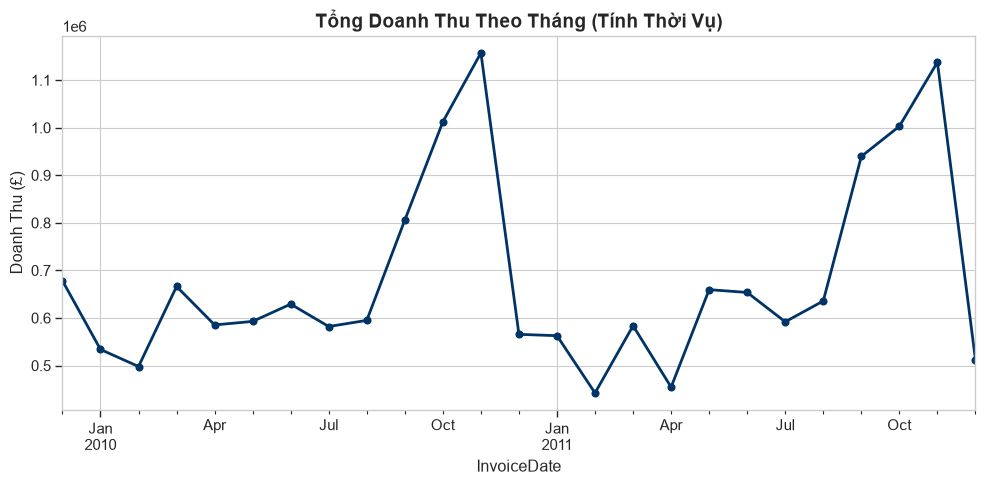

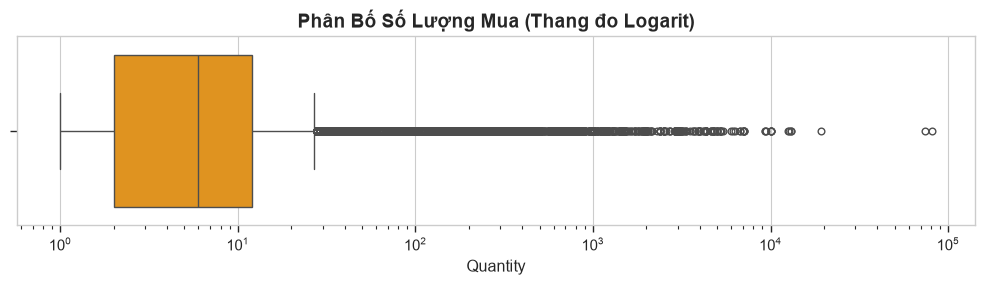

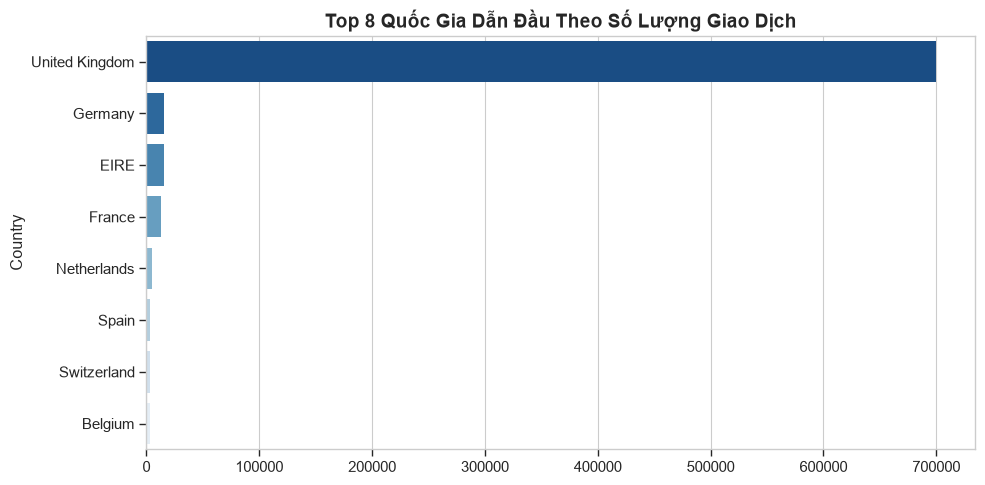

✅ Đã lưu ảnh thành công vào thư mục: docs


In [10]:
docs_dir = '../docs' if os.path.exists('../docs') else 'docs'
os.makedirs(docs_dir, exist_ok=True)

# 1. Tính thời vụ
plt.figure(figsize=(10, 5))
monthly_revenue = df_clean.set_index('InvoiceDate').resample('ME')['Revenue'].sum()
monthly_revenue.plot(kind='line', marker='o', color='#003366', linewidth=2)
plt.title('Tổng Doanh Thu Theo Tháng (Tính Thời Vụ)', fontsize=14, fontweight='bold')
plt.ylabel('Doanh Thu (£)')
plt.tight_layout()
plt.savefig(os.path.join(docs_dir, 'Bieu_Do_1_Thoi_Vu.png'), dpi=300)
plt.show()

# 2. Phân bố Số lượng (Thang đo Logarit)
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_clean['Quantity'], color='#ff9900')
plt.xscale('log') 
plt.title('Phân Bố Số Lượng Mua (Thang đo Logarit)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(docs_dir, 'Bieu_Do_2_Khach_Si_Le.png'), dpi=300)
plt.show()

# 3. Top Quốc gia
plt.figure(figsize=(10, 5))
top_countries = df_clean['Country'].value_counts().head(8)
sns.barplot(y=top_countries.index, x=top_countries.values, palette='Blues_r', hue=top_countries.index, legend=False)
plt.title('Top 8 Quốc Gia Dẫn Đầu Theo Số Lượng Giao Dịch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(docs_dir, 'Bieu_Do_3_Quoc_Gia.png'), dpi=300)
plt.show()

print(f"✅ Đã lưu ảnh thành công vào thư mục: {docs_dir}")

In [11]:
first_cutoff = pd.Timestamp('2010-08-01')
TOP_COUNTRIES = df_clean[df_clean['InvoiceDate'] < first_cutoff]['Country'].value_counts().head(8).index.tolist()

def tinh_rfm_co_ban(df_clean_input, cutoff_date):
    obs = df_clean_input[df_clean_input['InvoiceDate'] < cutoff_date]
    rfm = obs.groupby('Customer ID').agg(
        Recency=('InvoiceDate', lambda x: (cutoff_date - x.max()).days),
        Frequency=('Invoice', 'nunique'),
        Monetary=('Revenue', 'sum'),
        AvgOrderValue=('Revenue', 'mean'),
        NumProducts=('StockCode', 'nunique'),
        FirstPurchase=('InvoiceDate', 'min'),
        Country=('Country', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
    ).reset_index()
    return rfm

def them_interval_std(rfm_df, obs_df):
    def std_khoang_cach(dates):
        d = np.sort(dates.unique()) 
        if len(d) < 3: return np.nan
        diffs = np.diff(d) / np.timedelta64(1, 'D')
        return float(np.std(diffs))
    
    interval_std = obs_df.groupby('Customer ID')['InvoiceDate'].apply(std_khoang_cach).rename('IntervalStd').reset_index()
    out = rfm_df.merge(interval_std, on='Customer ID', how='left')
    out['IntervalStd'] = out['IntervalStd'].fillna(out['IntervalStd'].median())
    return out

def them_xu_huong(rfm_df, obs_df, cutoff_date):
    mid_point = cutoff_date - pd.Timedelta(days=90)
    far_point = cutoff_date - pd.Timedelta(days=180)
    
    rev_recent = obs_df[obs_df['InvoiceDate'] >= mid_point].groupby('Customer ID')['Revenue'].sum()
    rev_prev = obs_df[(obs_df['InvoiceDate'] >= far_point) & (obs_df['InvoiceDate'] < mid_point)].groupby('Customer ID')['Revenue'].sum()
    freq_recent = obs_df[obs_df['InvoiceDate'] >= mid_point].groupby('Customer ID')['Invoice'].nunique()
    freq_prev = obs_df[(obs_df['InvoiceDate'] >= far_point) & (obs_df['InvoiceDate'] < mid_point)].groupby('Customer ID')['Invoice'].nunique()
    
    trend = pd.concat([rev_recent.rename('rev_recent'), rev_prev.rename('rev_prev'),
                       freq_recent.rename('freq_recent'), freq_prev.rename('freq_prev')], axis=1).fillna(0)
    trend['SpendingTrend'] = trend['rev_recent'] - trend['rev_prev']
    trend['FrequencyTrend'] = trend['freq_recent'] - trend['freq_prev']
    trend = trend[['SpendingTrend', 'FrequencyTrend']].reset_index()
    
    out = rfm_df.merge(trend, on='Customer ID', how='left')
    out[['SpendingTrend', 'FrequencyTrend']] = out[['SpendingTrend', 'FrequencyTrend']].fillna(0)
    return out

def them_cancel_rate(rfm_df, df_raw_input, cutoff_date):
    obs_raw = df_raw_input[df_raw_input['InvoiceDate'] < cutoff_date]
    total = obs_raw.groupby('Customer ID')['Invoice'].nunique().rename('TotalInvoices')
    cancelled = obs_raw[obs_raw['is_cancelled']].groupby('Customer ID')['Invoice'].nunique().rename('CancelledInvoices')
    
    c = pd.concat([total, cancelled], axis=1).fillna(0)
    c['CancelRate'] = c['CancelledInvoices'] / c['TotalInvoices'].replace(0, np.nan)
    c = c[['CancelRate']].fillna(0).reset_index()
    out = rfm_df.merge(c, on='Customer ID', how='left')
    out['CancelRate'] = out['CancelRate'].fillna(0)
    return out

def them_repeat_purchase_ratio(rfm_df, obs_df, cutoff_date):
    tenure_months = ((cutoff_date - rfm_df['FirstPurchase']).dt.days / 30.44).clip(lower=1)
    active_months = obs_df.assign(ym=obs_df['InvoiceDate'].dt.to_period('M')).groupby('Customer ID')['ym'].nunique().rename('ActiveMonths')
    out = rfm_df.merge(active_months, on='Customer ID', how='left')
    out['ActiveMonths'] = out['ActiveMonths'].fillna(1)
    out['RepeatPurchaseRatio'] = (out['ActiveMonths'] / tenure_months).clip(upper=1.0)
    return out

def them_country_onehot(rfm_df, top_countries=TOP_COUNTRIES):
    cg = rfm_df['Country']
    dummies = pd.DataFrame({f'Country_{k}': (cg == k).astype(int) for k in top_countries})
    return pd.concat([rfm_df.reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)

def tinh_dac_trung_nang_cao(df_raw_input, df_clean_input, cutoff_date, top_countries=TOP_COUNTRIES):
    obs_clean = df_clean_input[df_clean_input['InvoiceDate'] < cutoff_date].copy()
    features = tinh_rfm_co_ban(df_clean_input, cutoff_date)
    features = them_interval_std(features, obs_clean)
    features = them_xu_huong(features, obs_clean, cutoff_date)
    features = them_cancel_rate(features, df_raw_input, cutoff_date)
    features = them_repeat_purchase_ratio(features, obs_clean, cutoff_date)
    features = them_country_onehot(features, top_countries)
    return features.drop(columns=['FirstPurchase', 'Country'])

print("✅ Đã khởi tạo hoàn tất các hàm Feature Engineering!")

✅ Đã khởi tạo hoàn tất các hàm Feature Engineering!


In [12]:
max_date = df_clean['InvoiceDate'].max()

def kiem_tra_va_gan_nhan(df_clean_input, cutoff_date, churn_window_days, max_date_input):
    required_end = cutoff_date + pd.Timedelta(days=churn_window_days)
    if required_end > max_date_input: return None, False
    
    obs = df_clean_input[df_clean_input['InvoiceDate'] < cutoff_date]
    future = df_clean_input[(df_clean_input['InvoiceDate'] >= cutoff_date) & (df_clean_input['InvoiceDate'] < required_end)]
    customers_before = obs['Customer ID'].unique()
    if len(customers_before) == 0: return None, False
    
    active_future = set(future['Customer ID'].unique())
    labels = pd.Series([0 if cid in active_future else 1 for cid in customers_before], index=customers_before, name='churn')
    return labels, True

def tao_cac_fold(window_months, test_cutoffs):
    return [(t - pd.DateOffset(months=2 * window_months),
             t - pd.DateOffset(months=window_months), t) for t in test_cutoffs]

# Tạo 8 mốc thời gian cách nhau 1 tháng (cửa sổ 3 tháng)
test_cutoffs_3m = [pd.Timestamp('2011-02-01') + pd.DateOffset(months=i) for i in range(8)]
folds_3m = tao_cac_fold(3, test_cutoffs_3m)

print("✅ Danh sách 8 fold thời gian chuẩn (Train - Val - Test):")
for tr, va, te in folds_3m:
    print(f"Train={tr.date()} | Val={va.date()} | Test={te.date()}")

✅ Danh sách 8 fold thời gian chuẩn (Train - Val - Test):
Train=2010-08-01 | Val=2010-11-01 | Test=2011-02-01
Train=2010-09-01 | Val=2010-12-01 | Test=2011-03-01
Train=2010-10-01 | Val=2011-01-01 | Test=2011-04-01
Train=2010-11-01 | Val=2011-02-01 | Test=2011-05-01
Train=2010-12-01 | Val=2011-03-01 | Test=2011-06-01
Train=2011-01-01 | Val=2011-04-01 | Test=2011-07-01
Train=2011-02-01 | Val=2011-05-01 | Test=2011-08-01
Train=2011-03-01 | Val=2011-06-01 | Test=2011-09-01


In [13]:
def data_tai_cutoff(cutoff, window_days=90):
    feats = tinh_dac_trung_nang_cao(df_raw, df_clean, cutoff)
    labels, is_valid = kiem_tra_va_gan_nhan(df_clean, cutoff, window_days, max_date)
    if not is_valid: return None
    return feats.merge(labels.rename('churn'), left_on='Customer ID', right_index=True)

model_configs = {
    'LogisticRegression': {
        'builder': lambda p, seed: LogisticRegression(random_state=seed, class_weight='balanced', max_iter=1000, **p),
        'param_grid': [{'C': 0.1}, {'C': 1.0}], 'needs_scaling': True, 'seeds': (0,)
    },
    'RandomForest': {
        'builder': lambda p, seed: RandomForestClassifier(random_state=seed, class_weight='balanced', n_jobs=-1, **p),
        'param_grid': [{'n_estimators': 200, 'max_depth': 5}, {'n_estimators': 300, 'max_depth': 8}],
        'needs_scaling': False, 'seeds': (0, 1, 2)
    },
    'XGBoost': {
        'builder': lambda p, seed: xgb.XGBClassifier(random_state=seed, eval_metric='logloss', **p),
        'param_grid': [{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}, {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}],
        'needs_scaling': False, 'seeds': (0,)
    },
    'LightGBM': {
        'builder': lambda p, seed: lgb.LGBMClassifier(random_state=seed, verbose=-1, **p),
        'param_grid': [{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}, {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}],
        'needs_scaling': False, 'seeds': (0,)
    }
}

def nguong_toi_uu_f1(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1 = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-9, None)
    return float(thresholds[int(np.argmax(f1))])

def chay_1_fold(model_name, feature_cols, train_c, val_c, test_c, window_days):
    cfg = model_configs[model_name]
    train = data_tai_cutoff(train_c, window_days)
    val = data_tai_cutoff(val_c, window_days)
    test = data_tai_cutoff(test_c, window_days)
    
    Xtr, Xva, Xte = train[feature_cols].copy(), val[feature_cols].copy(), test[feature_cols].copy()
    if cfg['needs_scaling']:
        scaler = StandardScaler().fit(Xtr)
        Xtr, Xva, Xte = scaler.transform(Xtr), scaler.transform(Xva), scaler.transform(Xte)
        
    roc_list, pr_list, extra_list = [], [], []
    for seed in cfg['seeds']:
        best_auc, best_params = -1, cfg['param_grid'][0]
        for params in cfg['param_grid']:
            model = cfg['builder'](params, seed).fit(Xtr, train['churn'])
            val_auc = roc_auc_score(val['churn'], model.predict_proba(Xva)[:, 1])
            if val_auc > best_auc: best_auc, best_params = val_auc, params
            
        final_model = cfg['builder'](best_params, seed).fit(Xtr, train['churn'])
        val_prob = final_model.predict_proba(Xva)[:, 1]
        test_prob = final_model.predict_proba(Xte)[:, 1]
        
        nguong = nguong_toi_uu_f1(val['churn'], val_prob)
        yhat = (test_prob >= nguong).astype(int)
        tn, fp, fn, tp = confusion_matrix(test['churn'], yhat, labels=[0, 1]).ravel()
        
        roc_list.append(roc_auc_score(test['churn'], test_prob))
        pr_list.append(average_precision_score(test['churn'], test_prob))
        extra_list.append([precision_score(test['churn'], yhat, zero_division=0), recall_score(test['churn'], yhat), f1_score(test['churn'], yhat), tn, fp, fn, tp])
        
    extra = np.mean(extra_list, axis=0)
    return {
        'roc_auc': float(np.mean(roc_list)), 'pr_auc': float(np.mean(pr_list)),
        'precision': extra[0], 'recall': extra[1], 'f1': extra[2]
    }

# Bắt đầu chạy vòng lặp
feature_cols = [c for c in data_tai_cutoff(pd.Timestamp('2010-08-01')).columns if c not in ('Customer ID', 'churn')]
print(f"🚀 Bắt đầu quá trình huấn luyện 4 mô hình. Có {len(feature_cols)} đặc trưng được đưa vào...")

ket_qua = {}
for name in model_configs:
    print(f"   -> Đang chạy {name} qua 8 fold...")
    ket_qua[name] = [chay_1_fold(name, feature_cols, tr, va, te, 90) for tr, va, te in folds_3m]

print("\n🏆 KẾT QUẢ TỔNG HỢP SAU HUẤN LUYỆN:")
for name, folds in ket_qua.items():
    roc = [f['roc_auc'] for f in folds]
    pr = [f['pr_auc'] for f in folds]
    print(f"{name:20s} | ROC-AUC: {np.mean(roc):.3f} +/- {np.std(roc, ddof=1):.3f}  |  PR-AUC: {np.mean(pr):.3f}")

🚀 Bắt đầu quá trình huấn luyện 4 mô hình. Có 19 đặc trưng được đưa vào...
   -> Đang chạy LogisticRegression qua 8 fold...
   -> Đang chạy RandomForest qua 8 fold...
   -> Đang chạy XGBoost qua 8 fold...
   -> Đang chạy LightGBM qua 8 fold...

🏆 KẾT QUẢ TỔNG HỢP SAU HUẤN LUYỆN:
LogisticRegression   | ROC-AUC: 0.795 +/- 0.012  |  PR-AUC: 0.854
RandomForest         | ROC-AUC: 0.798 +/- 0.014  |  PR-AUC: 0.855
XGBoost              | ROC-AUC: 0.771 +/- 0.020  |  PR-AUC: 0.831
LightGBM             | ROC-AUC: 0.769 +/- 0.021  |  PR-AUC: 0.831


In [14]:
import itertools

pivot_roc = {name: [f['roc_auc'] for f in folds] for name, folds in ket_qua.items()}

print("⚖️ KIỂM ĐỊNH WILCOXON GIỮA CÁC MÔ HÌNH (8 Fold Độc lập):")
for m1, m2 in itertools.combinations(model_configs.keys(), 2):
    stat_roc, p_roc = wilcoxon(pivot_roc[m1], pivot_roc[m2])
    thang = sum(a > b for a, b in zip(pivot_roc[m1], pivot_roc[m2]))
    print(f"{m1:20s} vs {m2:20s}: p-value = {p_roc:.4f}  ({m1} thắng {thang}/8 fold)")

print("\n🔪 ABLATION STUDY: GIÁ TRỊ CỦA NHÓM ĐẶC TRƯNG THỜI GIAN")
basic_cols = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'NumProducts']
temporal_extra = ['IntervalStd', 'SpendingTrend', 'FrequencyTrend', 'RepeatPurchaseRatio']

ket_qua_basic = [chay_1_fold('RandomForest', basic_cols, tr, va, te, 90) for tr, va, te in folds_3m]
ket_qua_temporal = [chay_1_fold('RandomForest', basic_cols + temporal_extra, tr, va, te, 90) for tr, va, te in folds_3m]

roc_basic = [f['roc_auc'] for f in ket_qua_basic]
roc_temporal = [f['roc_auc'] for f in ket_qua_temporal]
stat, p = wilcoxon(roc_basic, roc_temporal)

print(f"👉 RFM tĩnh cơ bản : ROC-AUC = {np.mean(roc_basic):.3f}")
print(f"👉 RFM + Thời gian : ROC-AUC = {np.mean(roc_temporal):.3f}")
print(f"📌 P-value = {p:.4f} (Mô hình bổ sung thời gian thắng {sum(a<b for a,b in zip(roc_basic, roc_temporal))}/8 fold)")

⚖️ KIỂM ĐỊNH WILCOXON GIỮA CÁC MÔ HÌNH (8 Fold Độc lập):
LogisticRegression   vs RandomForest        : p-value = 0.0547  (LogisticRegression thắng 1/8 fold)
LogisticRegression   vs XGBoost             : p-value = 0.0078  (LogisticRegression thắng 8/8 fold)
LogisticRegression   vs LightGBM            : p-value = 0.0078  (LogisticRegression thắng 8/8 fold)
RandomForest         vs XGBoost             : p-value = 0.0078  (RandomForest thắng 8/8 fold)
RandomForest         vs LightGBM            : p-value = 0.0078  (RandomForest thắng 8/8 fold)
XGBoost              vs LightGBM            : p-value = 0.5469  (XGBoost thắng 5/8 fold)

🔪 ABLATION STUDY: GIÁ TRỊ CỦA NHÓM ĐẶC TRƯNG THỜI GIAN
👉 RFM tĩnh cơ bản : ROC-AUC = 0.789
👉 RFM + Thời gian : ROC-AUC = 0.797
📌 P-value = 0.0078 (Mô hình bổ sung thời gian thắng 8/8 fold)
